In [1]:
# The Base libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import laspy

# The Deep Learning libraries
import torch
from segment_anything import sam_model_registry
from segment_anything import SamAutomaticMaskGenerator

In [2]:
MODEL = "../sam/sam_vit_h_4b8939.pth"


#Choose between cpu or cuda training. For cpu, input 'cpu' instead 'cuda:0'
USED_D = torch.device('cpu')

In [3]:
sam = sam_model_registry["vit_h"](checkpoint = MODEL)

#Cast your model to a specific device (cuda or cpu)
sam.to(device = USED_D)

/Users/alfredmikhael/Desktop/anaconda/anaconda3/envs/GEOSAM/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sta

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [37]:
def sam_masks(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    c_mask=[]
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.8)))
        c_mask.append(img)
    return c_mask

In [38]:
print('Mem allocated by other programs: ', torch.cuda.memory_allocated(), 'reserved:', torch.cuda.memory_reserved())
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"
import gc
gc.collect()
torch.cuda.empty_cache()

#If the GPU memory is not freed enough, try rebooting your (Windows) computer.
#ALSO, try using the following line if memory problems persist
mask_generator = SamAutomaticMaskGenerator(sam, points_per_batch=16)

Mem allocated by other programs:  0 reserved: 0


In [39]:
def cloud_to_image(pcd_np, resolution):
    minx = np.min(pcd_np[:, 0])
    maxx = np.max(pcd_np[:, 0])
    miny = np.min(pcd_np[:, 1])
    maxy = np.max(pcd_np[:, 1])
    width = int((maxx - minx) / resolution) + 1
    height = int((maxy - miny) / resolution) + 1
    image = np.zeros((height, width, 3), dtype=np.uint8)
    for point in pcd_np:
        x, y, *_ = point
        r, g, b = point[-3:]
        pixel_x = int((x - minx) / resolution)
        pixel_y = int((maxy - y) / resolution)
        image[pixel_y, pixel_x] = [r, g, b]
    return image

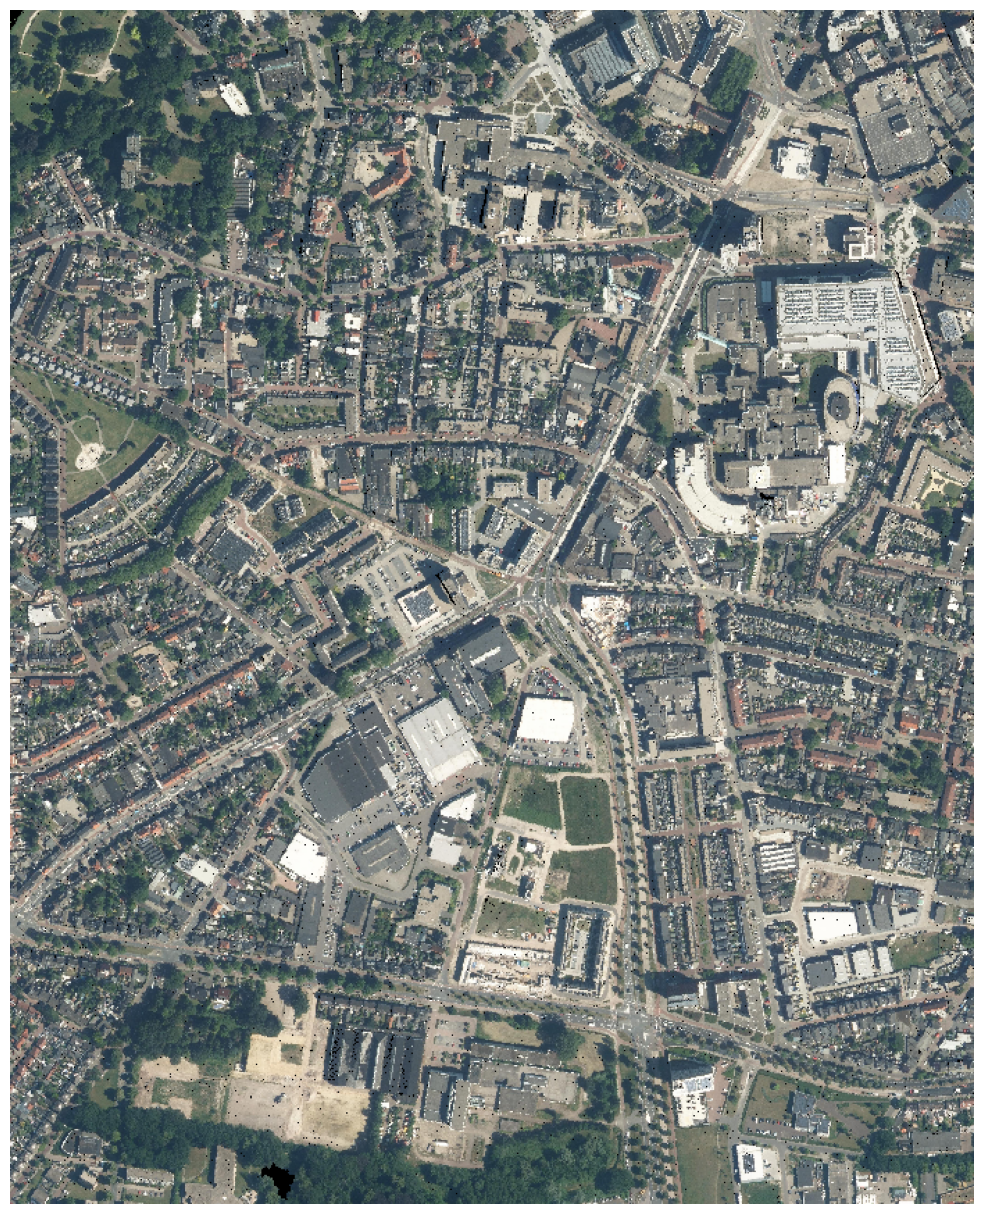

In [40]:
#Reading the point cloud with laspy
pcd = laspy.read("../sam/DATA/34FN2_18.las")

#Transforming the point cloud to Numpy
pcd_np = np.vstack((pcd.x, pcd.y, pcd.z, (pcd.red/65535*255).astype(int), (pcd.green/65535*255).astype(int), (pcd.blue/65535*255).astype(int))).transpose()

#Ortho-Projection
orthoimage = cloud_to_image(pcd_np, 1.5)

#Plotting and exporting
fig = plt.figure(figsize=(np.shape(orthoimage)[1]/72, np.shape(orthoimage)[0]/72))
fig.add_axes([0,0,1,1])
plt.imshow(orthoimage)
plt.axis('off')
plt.savefig("../sam/Testorthoimage.jpg")

In [45]:
def generate_spherical_image(center_coordinates, point_cloud, colors, resolution_y=500):
    # Translate the point cloud by the negation of the center coordinates
    translated_points = point_cloud - center_coordinates

    # Convert 3D point cloud to spherical coordinates
    theta = np.arctan2(translated_points[:, 1], translated_points[:, 0])
    phi = np.arccos(translated_points[:, 2] / np.linalg.norm(translated_points, axis=1))

    # Map spherical coordinates to pixel coordinates
    x = (theta + np.pi) / (2 * np.pi) * (2 * resolution_y)
    y = phi / np.pi * resolution_y

     # Create the spherical image with RGB channels
    resolution_x = 2 * resolution_y
    image = np.zeros((resolution_y, resolution_x, 3), dtype=np.uint8)

    # Create the mapping between point cloud and image coordinates
    mapping = np.full((resolution_y, resolution_x), -1, dtype=int)

    # Assign points to the image pixels
    for i in range(len(translated_points)):
        ix = np.clip(int(x[i]), 0, resolution_x - 1)
        iy = np.clip(int(y[i]), 0, resolution_y - 1)
        if mapping[iy, ix] == -1 or np.linalg.norm(translated_points[i]) < np.linalg.norm(translated_points[mapping[iy, ix]]):
            mapping[iy, ix] = i
            image[iy, ix] = colors[i]
    return image,mapping

In [46]:
#Loading the las file from the disk
las = laspy.read("../sam/DATA/ITC_BUILDING.las")

#Transforming to a numpy array
coords = np.vstack((las.x, las.y, las.z))
point_cloud = coords.transpose()

#Gathering the colors
r=(las.red/65535*255).astype(int)
g=(las.green/65535*255).astype(int)
b=(las.blue/65535*255).astype(int)
colors = np.vstack((r,g,b)).transpose()

In [47]:
resolution = 500

#Defining the position in the point cloud to generate a panorama
center_coordinates = [189, 60, 2]

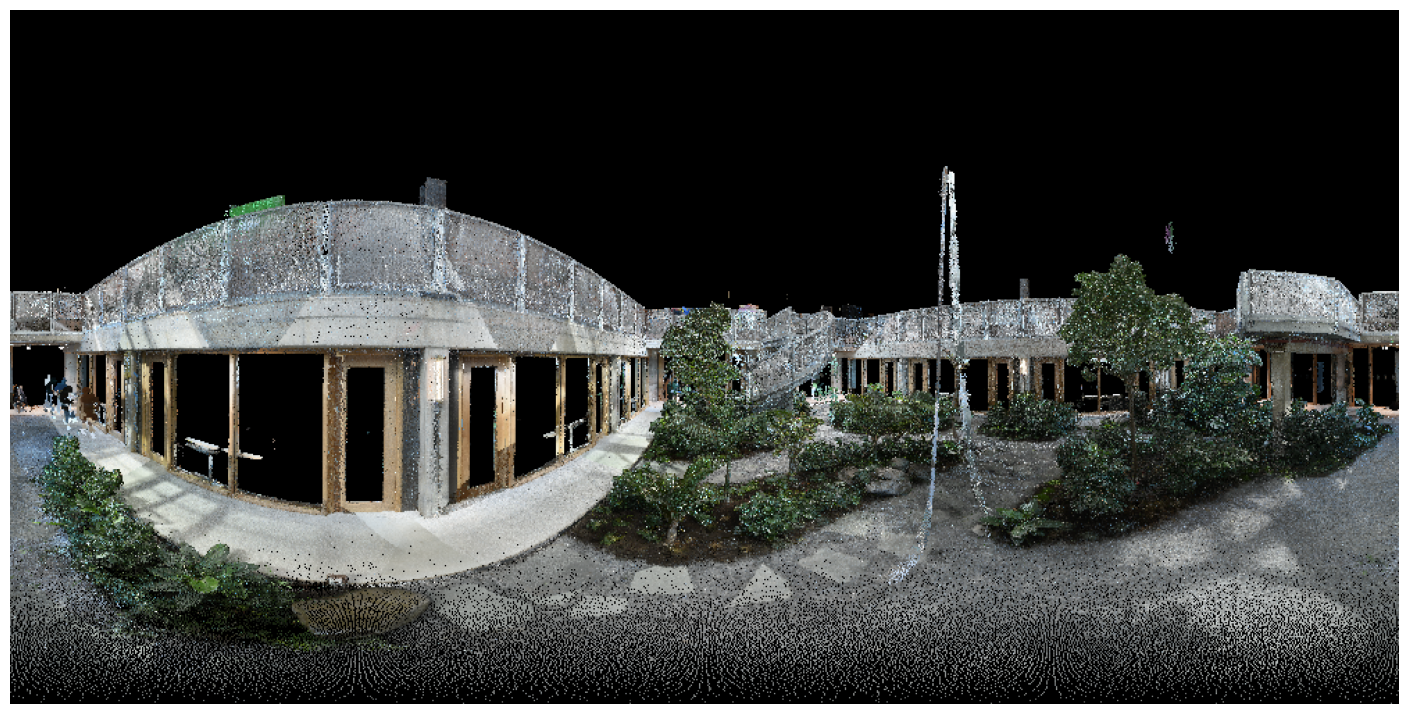

In [48]:
#Function Execution
spherical_image, mapping = generate_spherical_image(center_coordinates, point_cloud, colors, resolution)

#Plotting with matplotlib
fig = plt.figure(figsize=(np.shape(spherical_image)[1]/72, np.shape(spherical_image)[0]/72))
fig.add_axes([0,0,1,1])
plt.imshow(spherical_image)
plt.axis('off')

#Saving to the disk
plt.savefig("../sam/Test_spherical_projection.jpg")

In [50]:
sam = sam_model_registry["vit_h"](checkpoint = MODEL)
sam.to(device = USED_D)

mask_generator = SamAutomaticMaskGenerator(sam)

temp_img = cv2.imread("../sam/Test_spherical_projection.jpg")
image_rgb = cv2.cvtColor(temp_img, cv2.COLOR_BGR2RGB)


result = mask_generator.generate(image_rgb)


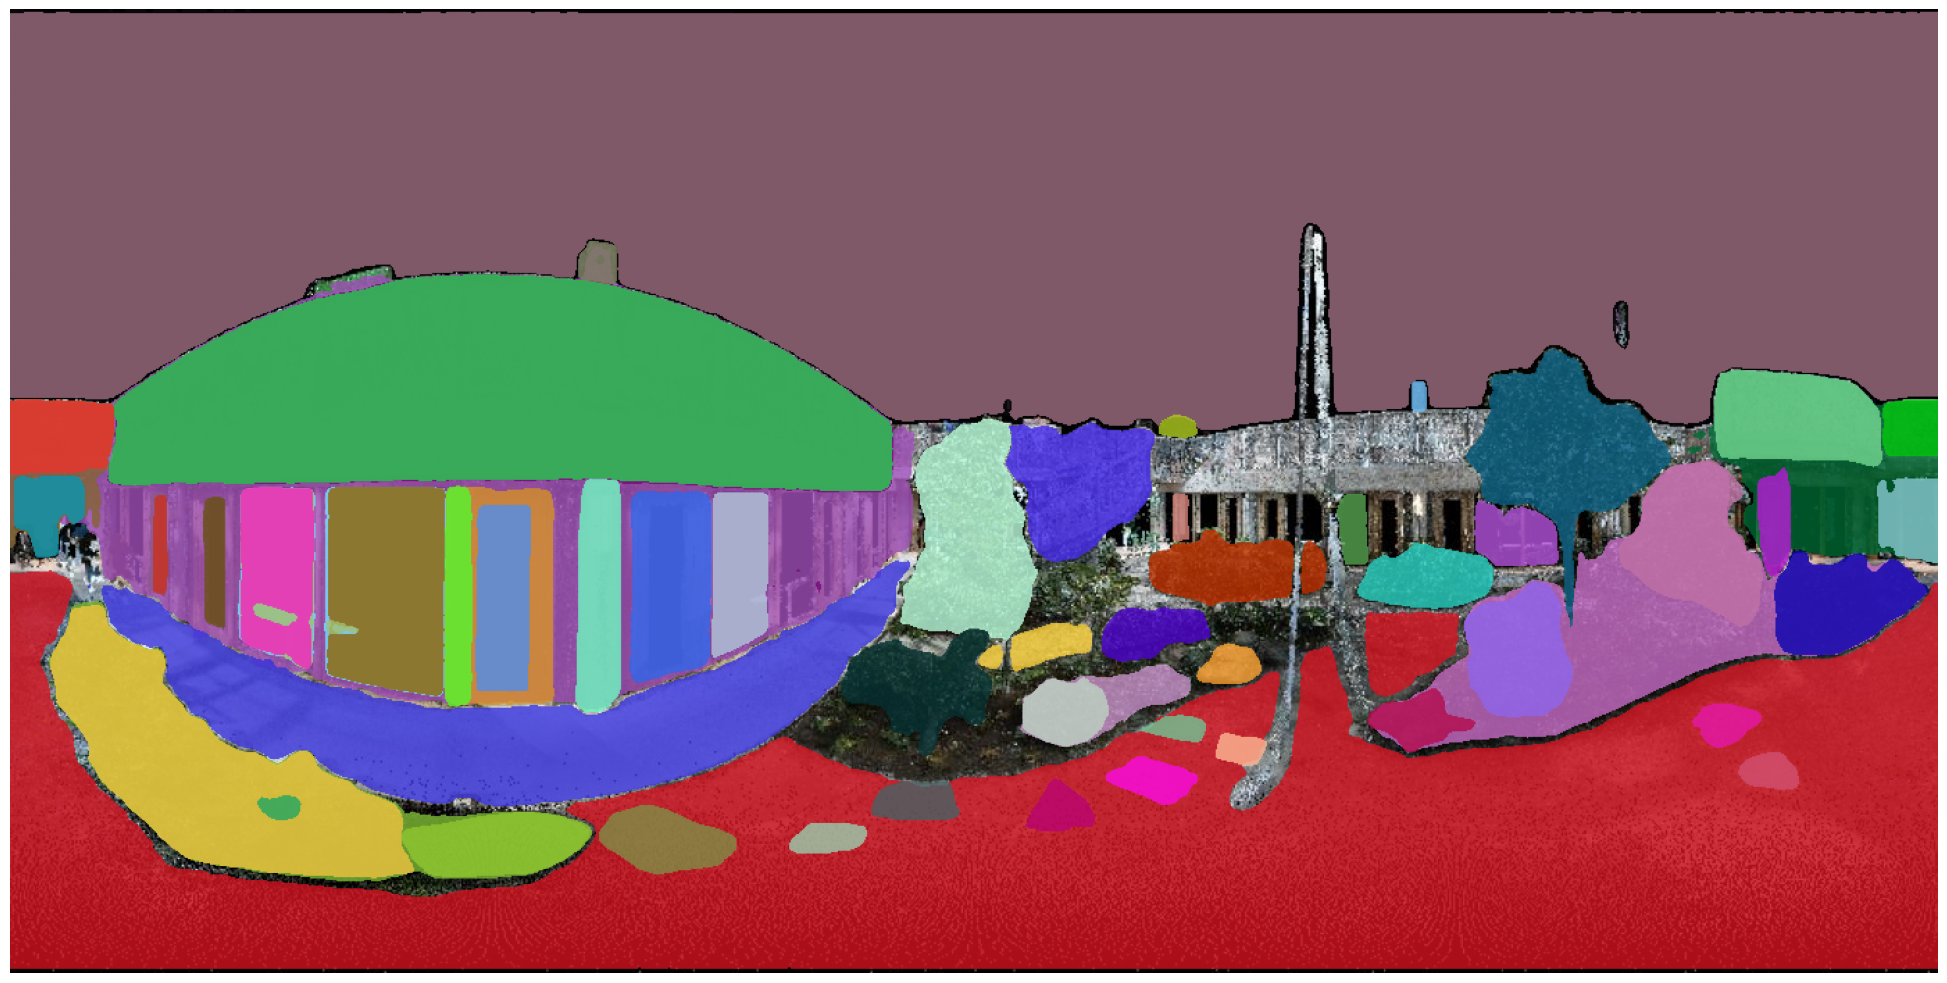

In [52]:
fig = plt.figure(figsize=(np.shape(image_rgb)[1]/72, np.shape(image_rgb)[0]/72))
fig.add_axes([0,0,1,1])

plt.imshow(image_rgb)
color_mask = sam_masks(result)
plt.axis('off')
plt.savefig("../sam/spherical_projection_segmented.jpg")

In [65]:
def color_point_cloud(image_path, point_cloud, mapping):
    import numpy as np
    import cv2

    # Load the image
    image = cv2.imread(image_path)
    original_h, original_w = image.shape[:2]

    # Resize image to match the mapping size
    image_resized = cv2.resize(image, (mapping.shape[1], mapping.shape[0]))
    resized_h, resized_w = image_resized.shape[:2]

    # Create the modified point cloud
    modified_point_cloud = np.zeros((point_cloud.shape[0], point_cloud.shape[1] + 3), dtype=np.float32)
    modified_point_cloud[:, :3] = point_cloud

    # Assign colors from the resized image to the point cloud
    for iy in range(resized_h):
        for ix in range(resized_w):
            point_index = mapping[iy, ix]

            # Skip invalid indices (-1) and ensure indices are within bounds
            if 0 <= point_index < point_cloud.shape[0]:
                color = image_resized[iy, ix]
                modified_point_cloud[point_index, 3:] = color

    return modified_point_cloud



In [66]:
print("Point cloud shape:", point_cloud.shape)
print("Mapping shape:", mapping.shape)
print("Mapping range:", np.min(mapping), np.max(mapping))

Point cloud shape: (7375201, 3)
Mapping shape: (500, 1000)
Mapping range: -1 7372497


In [67]:
image = cv2.imread("spherical_projection_segmented.jpg")
print("Image shape:", image.shape[:2])  # Should match (500, 1000)
print("Mapping shape:", mapping.shape)  # Should be (500, 1000)

Image shape: (963, 1927)
Mapping shape: (500, 1000)


In [68]:
modified_point_cloud = color_point_cloud("spherical_projection_segmented.jpg", point_cloud, mapping)

In [69]:
def export_point_cloud(cloud_path, modified_point_cloud):
    # 1. Create a new header
    header = laspy.LasHeader(point_format=3, version="1.2")
    header.add_extra_dim(laspy.ExtraBytesParams(name="random", type=np.int32))

    # 2. Create a Las
    las_o = laspy.LasData(header)
    las_o.x = modified_point_cloud[:,0]
    las_o.y = modified_point_cloud[:,1]
    las_o.z = modified_point_cloud[:,2]
    las_o.red = modified_point_cloud[:,3]
    las_o.green = modified_point_cloud[:,4]
    las_o.blue = modified_point_cloud[:,5]
    las_o.write(cloud_path)
    
    print("Export succesful at: ", cloud_path)
    return

In [70]:
export_point_cloud("../sam/sam_results.las", modified_point_cloud)

Export succesful at:  ../sam/sam_results.las
